# LME Copper Data — Cleaning and Exploratory Analysis

This notebook reads the incrementally collected Westmetall data, validates and cleans it, constructs analytical parameters, and explores relationships between copper prices and LME stock. The raw files are never modified.

## 1. Imports and adjustable parameters

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------- Parameters to experiment with ----------
START_DATE = None          # Example: '2015-01-01'; None keeps all observations
END_DATE = None            # Example: '2025-12-31'; None keeps all observations
ROLLING_WINDOWS = [5, 20, 60]  # Approx. week, month, and quarter in trading days
LAG_DAYS = range(-60, 61)  # Negative: stock leads price; positive: price leads stock
MIN_PERIODS_RATIO = 0.75   # Required fraction of observations in rolling windows
WINSORIZE_RETURNS = False  # Turn on only for sensitivity analysis
WINSOR_LIMITS = (0.01, 0.99)
SAVE_PROCESSED_DATA = False  # Change to True after reviewing the transformations

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

## 2. Locate and load the raw data

In [2]:
# This works whether Jupyter starts in the workspace, project, or notebooks directory.
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'projects' / 'copper']
PROJECT_DIR = next((root for root in candidate_roots if (root / 'data' / 'raw' / 'lme' / 'copper_lme_raw.csv').exists()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError('Could not locate data/raw/lme/copper_lme_raw.csv')

RAW_PATH = PROJECT_DIR / 'data' / 'raw' / 'lme' / 'copper_lme_raw.csv'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'

raw_df = pd.read_csv(RAW_PATH, dtype='string')
print(f'Raw path: {RAW_PATH.resolve()}')
print(f'Shape: {raw_df.shape}')
raw_df.head()

Raw path: C:\Work\commodity\copper\data\raw\lme\copper_lme_raw.csv
Shape: (4709, 7)


,date,cash_settlement,three_month,stock,source_year,fetched_at_utc,source_url
0,2008-01-02,"6,666.00","6,706.00","198,925",2008,2026-08-01T08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
1,2008-01-03,"6,765.00","6,818.00","198,175",2008,2026-08-01T08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
2,2008-01-04,"6,990.50","7,035.00","198,600",2008,2026-08-01T08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
3,2008-01-07,"6,915.50","6,950.50","201,000",2008,2026-08-01T08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
4,2008-01-08,"7,106.00","7,140.50","200,975",2008,2026-08-01T08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...


In [3]:
raw_df.info()
display(raw_df.tail())
display(raw_df.isna().sum().rename('empty_cells'))
display(raw_df.nunique().rename('unique_values'))

<class 'pandas.DataFrame'>
RangeIndex: 4709 entries, 0 to 4708
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             4709 non-null   string
 1   cash_settlement  4709 non-null   string
 2   three_month      4709 non-null   string
 3   stock            4709 non-null   string
 4   source_year      4709 non-null   string
 5   fetched_at_utc   4709 non-null   string
 6   source_url       4709 non-null   string
dtypes: string(7)
memory usage: 257.7 KB


,date,cash_settlement,three_month,stock,source_year,fetched_at_utc,source_url
4704,2026-08-10,"14,290.00","14,152.00","218,300",2026,2026-08-15T10:27:00+00:00,https://www.westmetall.com/en/markdaten.php?ac...
4705,2026-08-11,"14,424.50","14,217.00","214,550",2026,2026-08-15T10:27:00+00:00,https://www.westmetall.com/en/markdaten.php?ac...
4706,2026-08-12,"14,376.00","14,201.00","212,125",2026,2026-08-15T10:27:00+00:00,https://www.westmetall.com/en/markdaten.php?ac...
4707,2026-08-13,"14,285.00","14,082.00","207,725",2026,2026-08-15T10:27:00+00:00,https://www.westmetall.com/en/markdaten.php?ac...
4708,2026-08-14,"14,545.00","14,134.00","204,975",2026,2026-08-15T10:27:00+00:00,https://www.westmetall.com/en/markdaten.php?ac...


date               0
cash_settlement    0
three_month        0
stock              0
source_year        0
fetched_at_utc     0
source_url         0
Name: empty_cells, dtype: int64

date               4709
cash_settlement    3723
three_month        3446
stock              4040
source_year          19
fetched_at_utc       19
source_url           19
Name: unique_values, dtype: int64

## 3. Clean types and validate

A dash in the source means unavailable, so it becomes `NaN`. Numeric strings retain their original form in `raw_df`; cleaning happens only in `df`.

In [4]:
df = raw_df.copy()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='raise')

numeric_columns = ['cash_settlement', 'three_month', 'stock']
for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column].replace('-', pd.NA).str.replace(',', '', regex=False),
        errors='raise',
    )

df['source_year'] = pd.to_numeric(df['source_year'], errors='raise').astype('int16')
df['fetched_at_utc'] = pd.to_datetime(df['fetched_at_utc'], utc=True, errors='raise')
df = df.sort_values('date').reset_index(drop=True)

if START_DATE is not None:
    df = df.loc[df['date'] >= pd.Timestamp(START_DATE)].copy()
if END_DATE is not None:
    df = df.loc[df['date'] <= pd.Timestamp(END_DATE)].copy()

df.head()

,date,cash_settlement,three_month,stock,source_year,fetched_at_utc,source_url
0,2008-01-02,"6,666.0000","6,706.0000",198925,2008,2026-08-01 08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
1,2008-01-03,"6,765.0000","6,818.0000",198175,2008,2026-08-01 08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
2,2008-01-04,"6,990.5000","7,035.0000",198600,2008,2026-08-01 08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
3,2008-01-07,"6,915.5000","6,950.5000",201000,2008,2026-08-01 08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...
4,2008-01-08,"7,106.0000","7,140.5000",200975,2008,2026-08-01 08:38:18+00:00,https://www.westmetall.com/en/markdaten.php?ac...


In [5]:
quality_report = pd.Series({
    'rows': len(df),
    'first_date': df['date'].min(),
    'last_date': df['date'].max(),
    'duplicate_dates': df['date'].duplicated().sum(),
    'weekend_dates': (df['date'].dt.dayofweek >= 5).sum(),
    'missing_cash': df['cash_settlement'].isna().sum(),
    'missing_three_month': df['three_month'].isna().sum(),
    'missing_stock': df['stock'].isna().sum(),
    'source_year_mismatches': (df['date'].dt.year != df['source_year']).sum(),
    'nonpositive_numeric_values': (df[numeric_columns] <= 0).sum().sum(),
})
display(quality_report.to_frame('value'))

assert df['date'].is_monotonic_increasing
assert not df['date'].duplicated().any()
assert (df['date'].dt.year == df['source_year']).all()
assert not (df[numeric_columns] <= 0).any().any()

,value
rows,4709
first_date,2008-01-02 00:00:00
last_date,2026-08-14 00:00:00
duplicate_dates,0
weekend_dates,1
missing_cash,3
missing_three_month,3
missing_stock,1
source_year_mismatches,0
nonpositive_numeric_values,0


In [6]:
# Review exceptional observations instead of silently removing them.
exception_rows = df.loc[
    df[numeric_columns].isna().any(axis=1) | (df['date'].dt.dayofweek >= 5),
    ['date', *numeric_columns, 'source_url'],
]
exception_rows

,date,cash_settlement,three_month,stock,source_url
218,2008-11-08,"3,761.0000","3,815.0000",254800,https://www.westmetall.com/en/markdaten.php?ac...
1611,2014-05-19,<NA>,<NA>,186525,https://www.westmetall.com/en/markdaten.php?ac...
1616,2014-05-26,<NA>,<NA>,175850,https://www.westmetall.com/en/markdaten.php?ac...
2274,2016-12-27,<NA>,<NA>,334525,https://www.westmetall.com/en/markdaten.php?ac...
2377,2017-05-25,"5,665.0000","5,687.5000",<NA>,https://www.westmetall.com/en/markdaten.php?ac...


## 4. Construct analytical parameters

Returns and changes are preferable to raw levels for many correlation tests because price and inventory levels can both trend over time. The spread is cash minus three-month price; a positive value indicates backwardation and a negative value indicates contango.

In [7]:
df['spread'] = df['cash_settlement'] - df['three_month']
df['spread_pct'] = 100 * df['spread'] / df['three_month']
df['cash_return'] = df['cash_settlement'].pct_change(fill_method=None)
df['cash_log_return'] = np.log(df['cash_settlement']).diff()
df['three_month_return'] = df['three_month'].pct_change(fill_method=None)
df['stock_change'] = df['stock'].diff()
df['stock_pct_change'] = df['stock'].pct_change(fill_method=None)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

for window in ROLLING_WINDOWS:
    minimum = max(2, int(window * MIN_PERIODS_RATIO))
    df[f'cash_ma_{window}d'] = df['cash_settlement'].rolling(window, min_periods=minimum).mean()
    df[f'cash_volatility_{window}d'] = df['cash_log_return'].rolling(window, min_periods=minimum).std() * np.sqrt(252)
    df[f'stock_ma_{window}d'] = df['stock'].rolling(window, min_periods=minimum).mean()

if WINSORIZE_RETURNS:
    for column in ['cash_return', 'cash_log_return', 'three_month_return', 'stock_pct_change']:
        lower, upper = df[column].quantile(WINSOR_LIMITS)
        df[column] = df[column].clip(lower, upper)

df[['date', 'cash_settlement', 'three_month', 'stock', 'spread', 'cash_return', 'stock_pct_change']].tail()

C:\Work\Finenv\Lib\site-packages\pandas\core\arrays\masked.py:788: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


,date,cash_settlement,three_month,stock,spread,cash_return,stock_pct_change
4704,2026-08-10,"14,290.0000","14,152.0000",218300,138.0000,0.0035,-0.0210
4705,2026-08-11,"14,424.5000","14,217.0000",214550,207.5000,0.0094,-0.0172
4706,2026-08-12,"14,376.0000","14,201.0000",212125,175.0000,-0.0034,-0.0113
4707,2026-08-13,"14,285.0000","14,082.0000",207725,203.0000,-0.0063,-0.0207
4708,2026-08-14,"14,545.0000","14,134.0000",204975,411.0000,0.0182,-0.0132


## 5. Distributions and descriptive statistics

In [8]:
analysis_columns = [
    'cash_settlement', 'three_month', 'stock', 'spread', 'spread_pct',
    'cash_return', 'cash_log_return', 'stock_change', 'stock_pct_change',
]
display(df[analysis_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
cash_settlement,"4,706.0000","7,501.2638","1,968.5535","2,770.0000","3,343.3750","4,645.0000","6,096.2500","7,269.0000","8,795.8750","10,396.1250","13,510.3750","14,545.0000"
three_month,"4,706.0000","7,512.4313","1,971.6893","2,820.0000","3,390.0500","4,653.6250","6,105.0000","7,275.5000","8,824.7500","10,408.2500","13,566.6500","14,260.0000"
stock,"4,708.0000","258,832.4172","130,214.6708","51,175.0000","65,262.2500","84,051.2500","154,768.7500","242,287.5000","335,256.2500","510,555.0000","618,045.2500","678,225.0000"
spread,"4,706.0000",-11.1674,53.9888,-166.5000,-139.5000,-106.0000,-31.0000,-16.0000,7.0000,75.0000,182.8500,411.0000
spread_pct,"4,706.0000",-0.1533,0.6464,-2.7038,-1.5015,-1.2368,-0.4596,-0.2327,0.1035,1.0126,2.0320,4.0759
cash_return,"4,702.0000",0.0003,0.0153,-0.1116,-0.0428,-0.0235,-0.0076,0.0002,0.0086,0.0240,0.0417,0.1202
cash_log_return,"4,702.0000",0.0002,0.0153,-0.1184,-0.0438,-0.0238,-0.0076,0.0002,0.0085,0.0237,0.0409,0.1135
stock_change,"4,706.0000",2.7784,"4,959.3143","-20,200.0000","-7,748.7500","-4,975.0000","-2,075.0000",-625.0000,800.0000,"6,450.0000","23,616.2500","61,175.0000"
stock_pct_change,"4,706.0000",0.0003,0.0261,-0.1433,-0.0418,-0.0246,-0.0089,-0.0026,0.0035,0.0315,0.1102,0.4007


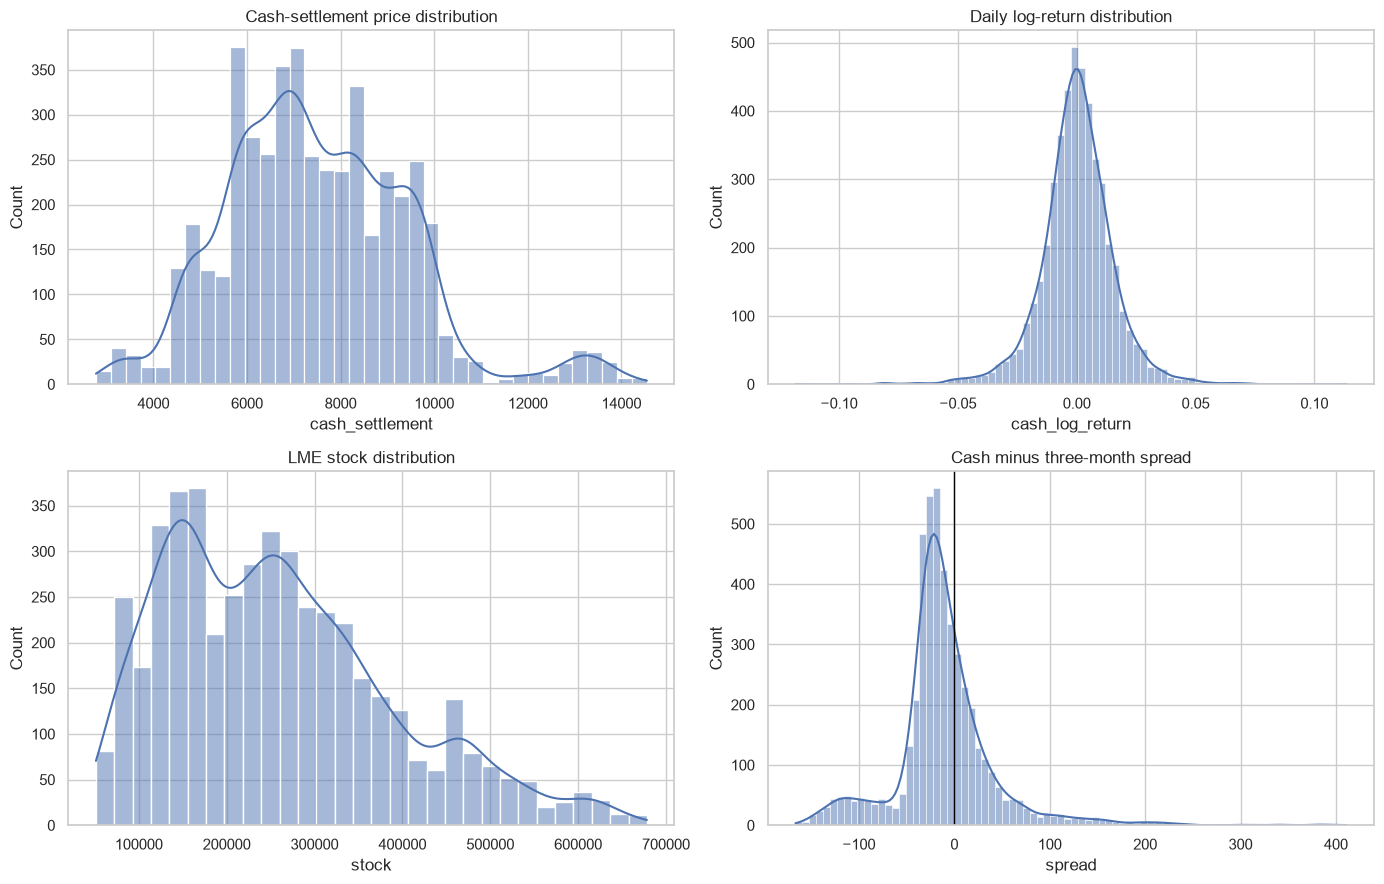

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(df['cash_settlement'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Cash-settlement price distribution')
sns.histplot(df['cash_log_return'].dropna(), bins=80, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Daily log-return distribution')
sns.histplot(df['stock'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('LME stock distribution')
sns.histplot(df['spread'].dropna(), bins=80, kde=True, ax=axes[1, 1])
axes[1, 1].axvline(0, color='black', linewidth=1)
axes[1, 1].set_title('Cash minus three-month spread')
plt.tight_layout()

## 6. Time-series behavior

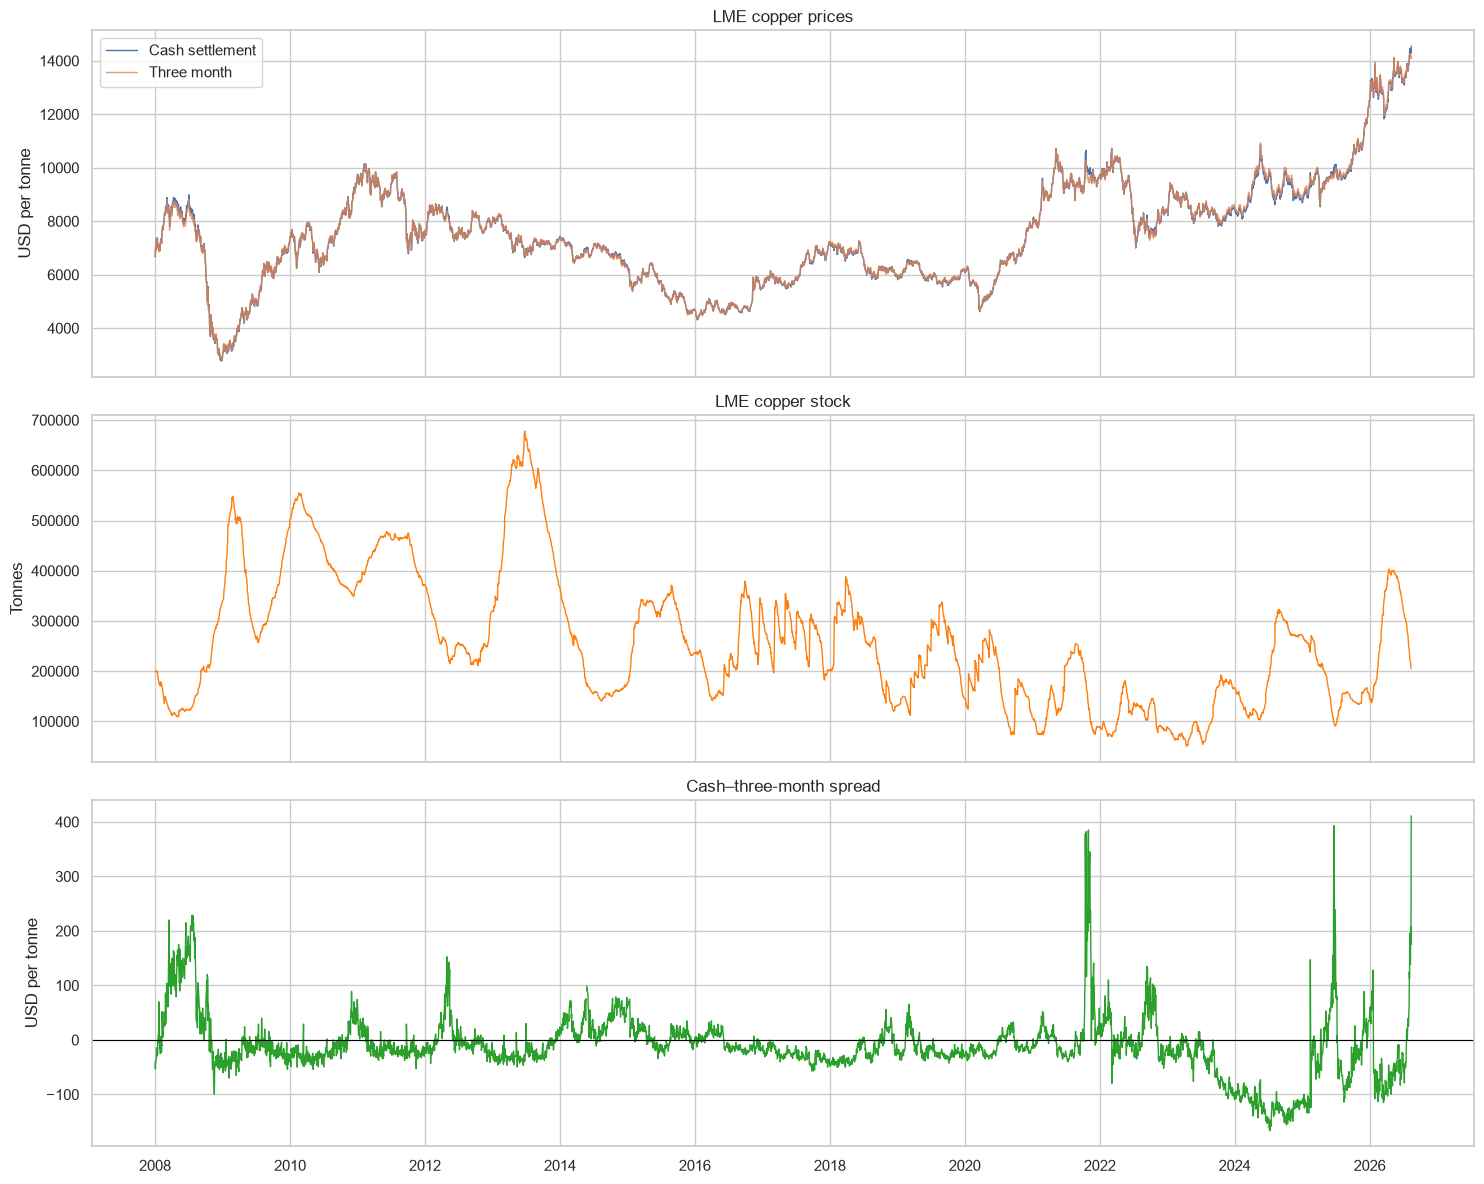

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
axes[0].plot(df['date'], df['cash_settlement'], label='Cash settlement', linewidth=1)
axes[0].plot(df['date'], df['three_month'], label='Three month', linewidth=1, alpha=0.8)
axes[0].set_ylabel('USD per tonne')
axes[0].legend()
axes[0].set_title('LME copper prices')
axes[1].plot(df['date'], df['stock'], color='tab:orange', linewidth=1)
axes[1].set_ylabel('Tonnes')
axes[1].set_title('LME copper stock')
axes[2].plot(df['date'], df['spread'], color='tab:green', linewidth=1)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('USD per tonne')
axes[2].set_title('Cash–three-month spread')
plt.tight_layout()

## 7. Correlations

Pearson measures linear association; Spearman measures monotonic association and is less sensitive to extreme observations. Correlation does not establish causality.

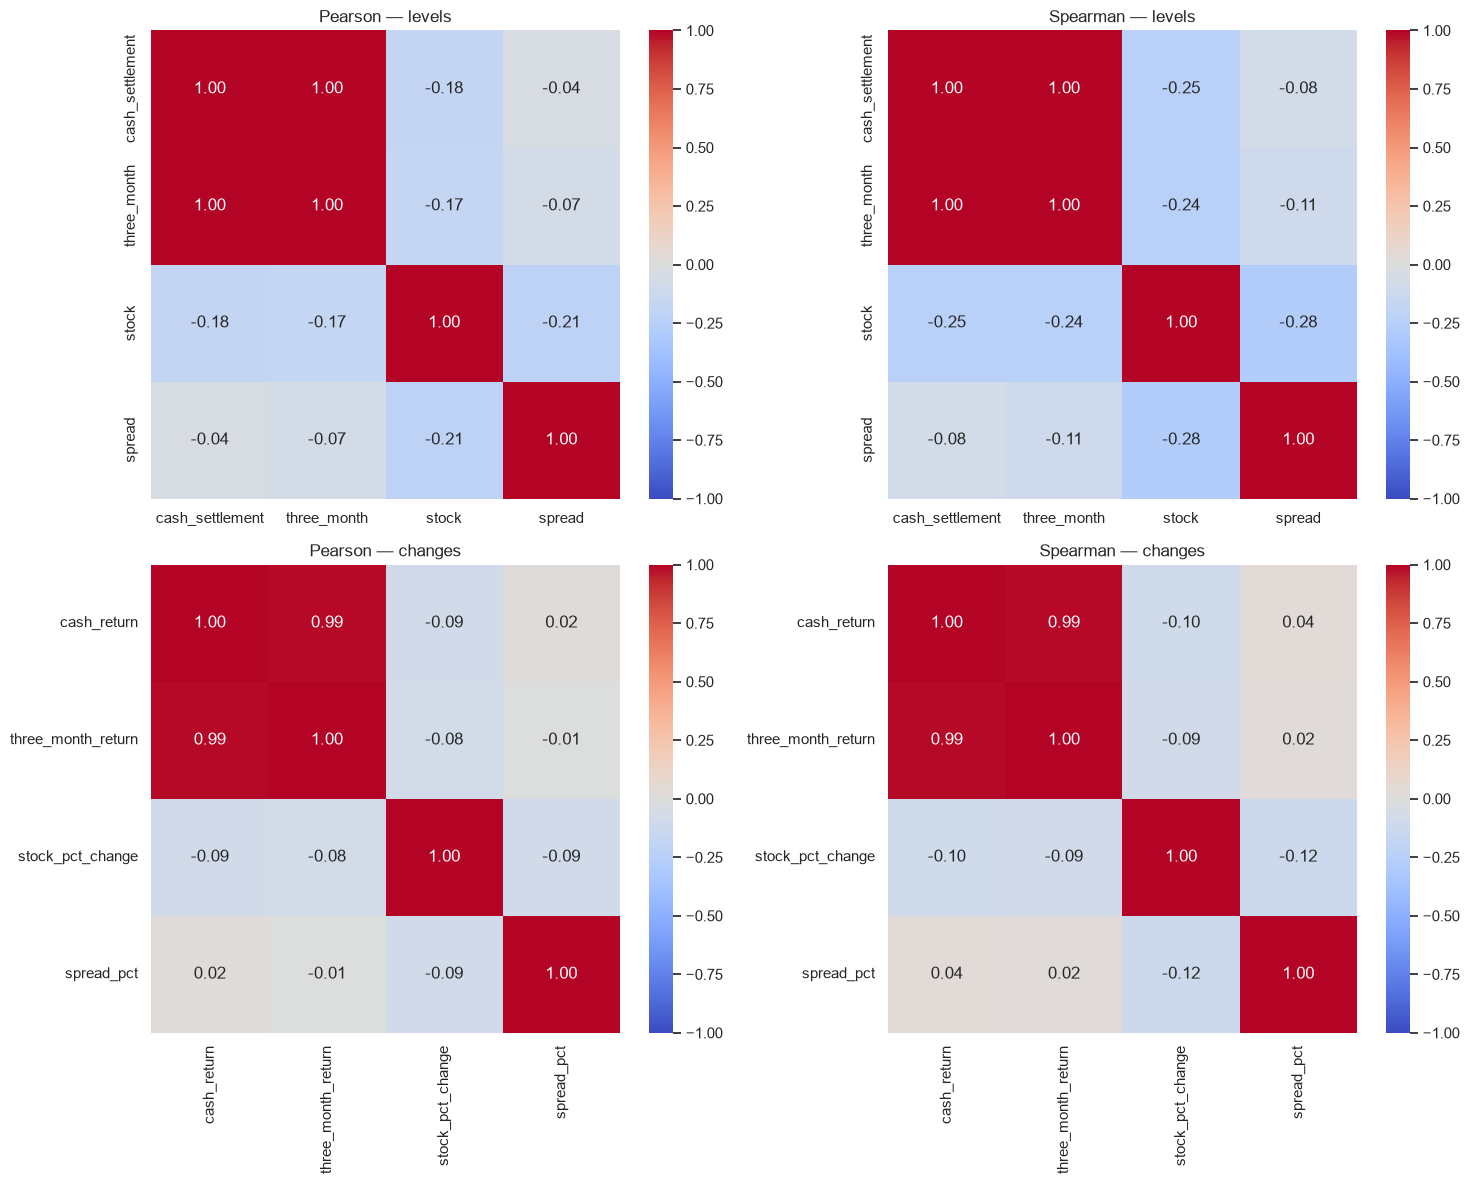

In [11]:
level_columns = ['cash_settlement', 'three_month', 'stock', 'spread']
change_columns = ['cash_return', 'three_month_return', 'stock_pct_change', 'spread_pct']

pearson_levels = df[level_columns].corr(method='pearson')
spearman_levels = df[level_columns].corr(method='spearman')
pearson_changes = df[change_columns].corr(method='pearson')
spearman_changes = df[change_columns].corr(method='spearman')

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for matrix, title, axis in [
    (pearson_levels, 'Pearson — levels', axes[0, 0]),
    (spearman_levels, 'Spearman — levels', axes[0, 1]),
    (pearson_changes, 'Pearson — changes', axes[1, 0]),
    (spearman_changes, 'Spearman — changes', axes[1, 1]),
]:
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axis)
    axis.set_title(title)
plt.tight_layout()

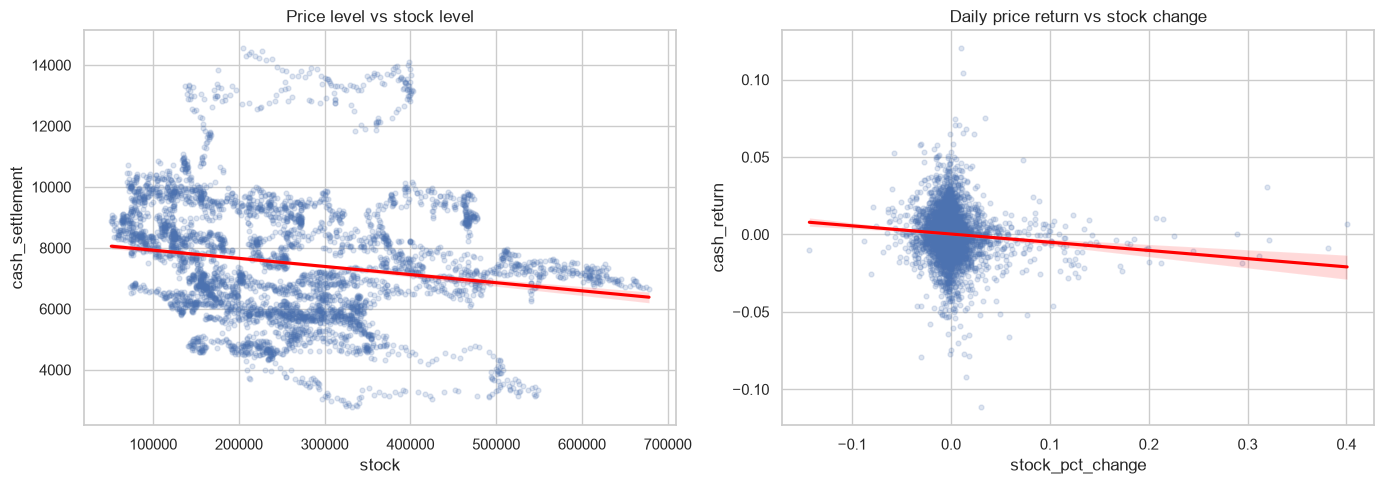

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=df, x='stock', y='cash_settlement', scatter_kws={'alpha': 0.18, 's': 12}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('Price level vs stock level')
sns.regplot(data=df, x='stock_pct_change', y='cash_return', scatter_kws={'alpha': 0.18, 's': 12}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Daily price return vs stock change')
plt.tight_layout()

## 8. Lagged relationships

This checks whether changes in stock tend to precede or follow price returns. It uses observation lags (trading rows), not exact calendar days.

,lag,pearson,spearman
28,-32,0.0356,0.0312
48,-12,-0.0301,-0.0514
52,-8,-0.0361,-0.0433
55,-5,-0.0284,-0.0396
57,-3,-0.0452,-0.0546
59,-1,-0.0437,-0.0524
60,0,-0.0904,-0.0978
61,1,-0.0492,-0.0446
62,2,-0.0350,-0.0460
66,6,-0.0330,-0.0297


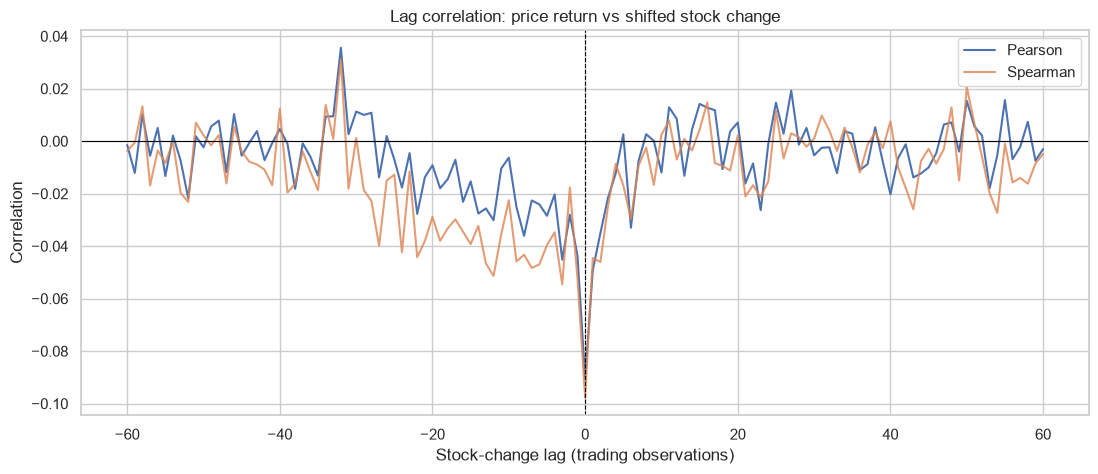

In [13]:
lag_correlations = pd.DataFrame({
    'lag': list(LAG_DAYS),
    'pearson': [df['cash_return'].corr(df['stock_pct_change'].shift(lag), method='pearson') for lag in LAG_DAYS],
    'spearman': [df['cash_return'].corr(df['stock_pct_change'].shift(lag), method='spearman') for lag in LAG_DAYS],
})

display(lag_correlations.loc[lag_correlations['pearson'].abs().nlargest(10).index].sort_values('lag'))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(lag_correlations['lag'], lag_correlations['pearson'], label='Pearson')
ax.plot(lag_correlations['lag'], lag_correlations['spearman'], label='Spearman', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set(title='Lag correlation: price return vs shifted stock change', xlabel='Stock-change lag (trading observations)', ylabel='Correlation')
ax.legend()
plt.show()

## 9. Correlation stability over time

In [14]:
yearly_summary = (
    df.groupby('year')
      .agg(
          observations=('date', 'size'),
          average_cash=('cash_settlement', 'mean'),
          year_end_cash=('cash_settlement', 'last'),
          average_stock=('stock', 'mean'),
          average_spread=('spread', 'mean'),
          annualized_volatility=('cash_log_return', lambda x: x.std() * np.sqrt(252)),
      )
)
yearly_summary['price_stock_level_corr'] = df.groupby('year')[['cash_settlement', 'stock']].apply(
    lambda group: group['cash_settlement'].corr(group['stock'])
)
yearly_summary['return_stock_change_corr'] = df.groupby('year')[['cash_return', 'stock_pct_change']].apply(
    lambda group: group['cash_return'].corr(group['stock_pct_change'])
)
display(yearly_summary)

,observations,average_cash,year_end_cash,average_stock,average_spread,annualized_volatility,price_stock_level_corr,return_stock_change_corr
year,,,,,,,,
2008,255,"6,939.0039","2,902.0000","175,678.1373",67.3137,0.4611,-0.9580,-0.0943
2009,253,"5,163.5949","7,346.0000","386,777.2727",-21.8142,0.3925,-0.3662,-0.0855
2010,253,"7,539.3241","9,739.5000","446,366.2055",-15.5455,0.2736,-0.5921,-0.0091
2011,251,"8,810.9024","7,554.0000","437,220.1195",-13.7510,0.2907,0.1046,-0.0596
2012,252,"7,949.7063","7,915.0000","260,287.9960",3.5278,0.1906,0.2591,-0.0306
2013,253,"7,322.0000","7,394.5000","523,259.8814",-23.8043,0.1768,-0.6774,-0.1766
2014,254,"6,861.4187","6,359.0000","202,894.5866",33.7500,0.1324,0.3812,-0.1172
2015,253,"5,494.4980","4,702.0000","302,281.7194",7.5830,0.2088,0.2788,-0.1969
2016,254,"4,862.5870","5,501.0000","234,937.0079",-4.5534,0.2112,0.0922,-0.2494


In [15]:
monthly = (
    df.set_index('date')
      .resample('ME')
      .agg({
          'cash_settlement': 'last',
          'three_month': 'last',
          'stock': 'last',
          'spread': 'mean',
          'cash_log_return': 'std',
      })
)
monthly['cash_monthly_return'] = monthly['cash_settlement'].pct_change(fill_method=None)
monthly['stock_monthly_change'] = monthly['stock'].pct_change(fill_method=None)
monthly['monthly_volatility'] = monthly['cash_log_return'] * np.sqrt(252)

display(monthly.tail(12))
display(monthly[['cash_monthly_return', 'stock_monthly_change', 'spread']].corr())

,cash_settlement,three_month,stock,spread,cash_log_return,cash_monthly_return,stock_monthly_change,monthly_volatility
date,,,,,,,,
2025-09-30,"10,300.0000","10,332.0000",143400,-70.4773,0.0123,0.0505,-0.0975,0.1949
2025-10-31,"10,901.5000","10,920.0000",134625,-24.3913,0.0103,0.0584,-0.0612,0.1631
2025-11-30,"11,004.0000","10,985.5000",159425,-13.5000,0.0097,0.0094,0.1842,0.1546
2025-12-31,"12,504.0000","12,466.0000",147425,28.5238,0.0091,0.1363,-0.0753,0.1444
2026-01-31,"13,369.5000","13,445.0000",174975,18.4048,0.0221,0.0692,0.1869,0.3501
2026-02-28,"13,439.5000","13,484.0000",253700,-81.6250,0.0172,0.0052,0.4499,0.2724
2026-03-31,"12,160.0000","12,236.0000",362425,-84.3182,0.0164,-0.0952,0.4286,0.2596
2026-04-30,"13,015.5000","13,090.0000",399725,-78.5000,0.0109,0.0704,0.1029,0.1734
2026-05-31,"13,615.0000","13,656.5000",389425,-57.2368,0.0128,0.0461,-0.0258,0.2039


,cash_monthly_return,stock_monthly_change,spread
cash_monthly_return,1.0000,-0.2865,-0.0231
stock_monthly_change,-0.2865,1.0000,-0.1853
spread,-0.0231,-0.1853,1.0000


## 10. Optional processed-data export

Review all transformations first. When satisfied, set `SAVE_PROCESSED_DATA = True` in the parameter cell and rerun.

In [16]:
if SAVE_PROCESSED_DATA:
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    processed_path = PROCESSED_DIR / 'copper_lme_processed.csv'
    df.to_csv(processed_path, index=False)
    print(f'Saved {len(df):,} rows to {processed_path.resolve()}')
else:
    print('Export skipped. Set SAVE_PROCESSED_DATA = True when ready.')

Export skipped. Set SAVE_PROCESSED_DATA = True when ready.
